# Exp3 – Fine-tuning Demo & AUPRC Visualisation

This notebook demonstrates:

1. **Model architecture** – `CrossCellDNaseClassifier` (GROVER backbone + 1D-CNN DNase fusion)
2. **Smoke-test training** – 1 epoch on 500 CTCF samples (verifies the pipeline without a full run)
3. **AUPRC comparison plot** – sequence-only vs. sequence+DNase across all 6 TFs and all models, using the pre-computed results from the full training runs

**TF / model for demo:** CTCF × GROVER-frozen  
**Conda env:** `glm_hf`

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import warnings
warnings.filterwarnings('ignore')

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Paths
DATASET_DIR = (
    '/dataset/zjn_zjj/DLM/10_21_previous_work/'
    'Data_associated_with_Graduation/DNase_implement/'
    'Data/dataset/imbalanced'
)
CTCF_TRAIN = f'{DATASET_DIR}/train/CTCF_train_merged.h5'
CTCF_VAL   = f'{DATASET_DIR}/val/CTCF_val_merged.h5'
CTCF_TEST  = f'{DATASET_DIR}/test/CTCF_test_GM12878.h5'

GROVER_PATH = '/dataset/zjn_zjj/DLM/GFM_model_files/GROVER'

# Root of full training outputs (for AUPRC plot)
RESULTS_ROOT = (
    '/dataset/zjn_zjj/DLM/10_21_previous_work/'
    'Data_associated_with_Graduation/DNase_implement'
)

print('CUDA available:', torch.cuda.is_available())
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CUDA available: True
Device: cuda:0


---
## 1. Model Architecture

```
DNA sequence (1000 nt)
      │
      ▼  BPE tokeniser (GROVER / DNABERT-2 / GENA-LM)
  token ids  (B, L)
      │
      ▼  frozen DNA-LM backbone
  hidden states  (B, L, D=768)
      │
      │   DNase signal (B, 1000)  →  1D-CNN expander  →  (B, L, D)
      │                                                        │
      └──────────────── concat → (B, L, 2D) ─────────────────┘
                             │
                      LayerNorm + Linear + GELU + Dropout  →  (B, L, D)
                             │  mean-pool over valid tokens
                      LayerNorm + Linear(D→D/2) + GELU + Dropout
                             │
                      Linear(D/2→2)  →  logits  →  CrossEntropy
```

**1D-CNN expander** maps 1D DNase signal to per-token embeddings:
- Conv1d(1→64, k=7) → ReLU → BN
- Conv1d(64→128, k=5) → ReLU → BN  
- Conv1d(128→768, k=3)

In [2]:
from transformers import AutoTokenizer
from exp3_dnase.finetune.finetune_BPE import CrossCellDNaseClassifier

tokenizer = AutoTokenizer.from_pretrained(GROVER_PATH, trust_remote_code=True)
tokenizer.model_max_length = 1002

model = CrossCellDNaseClassifier(
    model_name='GROVER',
    model_path=GROVER_PATH,
    hidden_dim=768,
    freeze_backbone=True,   # backbone weights frozen; only fusion + classifier trained
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:>12,}')
print(f'Trainable parameters: {trainable_params:>12,}  ({trainable_params/total_params*100:.1f}%)')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /dataset/zjn_zjj/DLM/GFM_model_files/GROVER and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters    :   88,329,348
Trainable parameters:    1,818,754  (2.1%)


---
## 2. Dataset (smoke-test subset)

We draw `max_samples=500` for a quick smoke test.  
For the full run use `bash scripts/04_finetune_BPE.sh CTCF --model_name GROVER`.

In [3]:
from exp3_dnase.finetune.finetune_BPE import CrossCellDNaseDataset, DataCollatorForCrossCellDNase
from torch.utils.data import DataLoader

MAX_SAMPLES = 500

train_ds = CrossCellDNaseDataset(CTCF_TRAIN, tokenizer, split='train', max_samples=MAX_SAMPLES)
val_ds   = CrossCellDNaseDataset(CTCF_VAL,   tokenizer, split='val',   max_samples=100)
test_ds  = CrossCellDNaseDataset(CTCF_TEST,  tokenizer, split='test',  max_samples=100)

collator = DataCollatorForCrossCellDNase(tokenizer)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  collate_fn=collator)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=collator)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

# Inspect one batch
batch = next(iter(train_loader))
print('\nBatch keys:', list(batch.keys()))
print('input_ids    :', batch['input_ids'].shape)
print('dnase_signals:', batch['dnase_signals'].shape)
print('labels       :', batch['labels'].shape, '→', batch['labels'].tolist())

Loading train data from /dataset/zjn_zjj/DLM/10_21_previous_work/Data_associated_with_Graduation/DNase_implement/Data/dataset/imbalanced/train/CTCF_train_merged.h5 ...
  86,157 samples, 26,295 positive (30.5%)
Loading val data from /dataset/zjn_zjj/DLM/10_21_previous_work/Data_associated_with_Graduation/DNase_implement/Data/dataset/imbalanced/val/CTCF_val_merged.h5 ...
  9,572 samples, 2,921 positive (30.5%)
Loading test data from /dataset/zjn_zjj/DLM/10_21_previous_work/Data_associated_with_Graduation/DNase_implement/Data/dataset/imbalanced/test/CTCF_test_GM12878.h5 ...
  2,613 samples, 756 positive (28.9%)
Train batches: 63
Val   batches: 7


You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Batch keys: ['input_ids', 'attention_mask', 'dnase_signals', 'labels']
input_ids    : torch.Size([8, 278])
dnase_signals: torch.Size([8, 278])
labels       : torch.Size([8]) → [0, 1, 0, 1, 0, 0, 0, 0]


---
## 3. Smoke-test Training (1 Epoch)

We train for exactly **1 epoch on 500 samples** to verify the pipeline end-to-end.  
Class-weighted loss `[1.0, 5.0]` handles the positive minority class.

> **Note:** This smoke test does not produce meaningful AUPRC results.  
> For publication-quality results see the pre-computed outputs loaded in Section 4.

In [4]:
from sklearn.metrics import average_precision_score

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5, weight_decay=0.01,
)
class_weights = torch.tensor([1.0, 5.0], device=device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# ── 1-epoch smoke train ──
model.train()
total_loss = 0.0
for step, batch in enumerate(train_loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    logits = model(
        input_ids      = batch['input_ids'],
        attention_mask = batch['attention_mask'],
        dnase_signals  = batch['dnase_signals'],
    )
    loss = criterion(logits, batch['labels'])
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    total_loss += loss.item()
    if (step + 1) % 10 == 0:
        print(f'  step {step+1:3d}/{len(train_loader)}  loss={loss.item():.4f}')

print(f'\nEpoch done. Mean train loss: {total_loss/len(train_loader):.4f}')

  step  10/63  loss=0.6513
  step  20/63  loss=0.6985
  step  30/63  loss=0.5823
  step  40/63  loss=0.6327
  step  50/63  loss=0.4336
  step  60/63  loss=0.4231

Epoch done. Mean train loss: 0.6474


In [5]:
# Quick eval on the 100-sample val subset
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(
            input_ids      = batch['input_ids'],
            attention_mask = batch['attention_mask'],
            dnase_signals  = batch['dnase_signals'],
        )
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(batch['labels'].cpu().numpy().tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

if all_labels.sum() > 0:
    smoke_auprc = average_precision_score(all_labels, all_probs)
    print(f'Smoke-test val AUPRC (1 epoch, 500 samples): {smoke_auprc:.4f}')
    print('(Baseline is label prevalence ~{:.2f})'.format(all_labels.mean()))
else:
    print('No positive labels in this small val subset – expected for a tiny sample.')

Smoke-test val AUPRC (1 epoch, 500 samples): 0.5183
(Baseline is label prevalence ~0.39)


### Running the full fine-tuning via shell

To reproduce the published results, run the numbered shell scripts in order:

```bash
# All TFs, all BPE models
for TF in BRD4 CTCF EZH2 GABPA POLR2A USF2; do
    for MODEL in DNABERT2 GROVER GENA_LM_BERT; do
        bash scripts/04_finetune_BPE.sh $TF --model_name $MODEL
    done
    bash scripts/05_finetune_NT.sh    $TF
    bash scripts/06_finetune_hyena.sh $TF
done

# Aggregate and plot
bash scripts/07_extract_auprc.sh
bash scripts/08_plot_auprc.sh
```

Results land in `scripts/outputs/{TF}/{model_type}/{model_name}_{frozen}/results/`.

---
## 4. AUPRC Comparison Plot

We load the **pre-computed** result JSONs from the full training runs (all 6 TFs × all models)  
and reproduce the 2×3 subplot figure comparing sequence-only vs. sequence+DNase AUPRC.

This is the same logic as `src/exp3_dnase/analysis/plot_auprc.py` (also callable via `scripts/08_plot_auprc.sh`).

In [6]:
from pathlib import Path

TF_LIST = ['BRD4', 'CTCF', 'EZH2', 'GABPA', 'POLR2A', 'USF2']

MODEL_LABELS = {
    'Basic':            'Basic',
    'dnabert2_117m':    'DNABERT-2',
    'ntv2_500m_multi':  'NTv2-500M',
    'gena_bigbird_t2t': 'GENA-Bert',
    'grover':           'GROVER',
    'hyenadna_large_1m':'HyenaDNA',
}
MODEL_COLORS = {
    'Basic':            '#E75D5D',
    'dnabert2_117m':    '#3B6EA8',
    'ntv2_500m_multi':  '#D95F02',
    'gena_bigbird_t2t': '#2A9D8F',
    'grover':           '#7A5195',
    'hyenadna_large_1m':'#6C757D',
}
MODEL_KEY_TO_PATTERN = {
    'Basic':            'Basic',
    'dnabert2_117m':    'DNABERT2',
    'grover':           'GROVER',
    'gena_bigbird_t2t': 'GENA_LM_BERT',
    'ntv2_500m_multi':  'NT',
    'hyenadna_large_1m':'Hyena',
}

SEQUENCE_ONLY_PATTERNS = {
    'Basic':       'scripts/finetune/without_DNase_5.1/outputs/{tf}/Basic/256d_sequence_only_unfrozen/results/test_results.json',
    'DNABERT2':    'scripts/finetune/without_DNase_5.1/outputs/{tf}/BPE/DNABERT2_sequence_only_frozen/results/test_results.json',
    'GROVER':      'scripts/finetune/without_DNase_5.1/outputs/{tf}/BPE/GROVER_sequence_only_frozen/results/test_results.json',
    'GENA_LM_BERT':'scripts/finetune/without_DNase_5.1/outputs/{tf}/BPE/GENA_LM_BERT_sequence_only_frozen/results/test_results.json',
    'NT':          'scripts/finetune/without_DNase_5.1/outputs/{tf}/NT/NT_sequence_only_frozen/results/test_results.json',
    'Hyena':       'scripts/finetune/without_DNase_5.1/outputs/{tf}/Hyena/hyena-small_sequence_only_frozen/results/test_results.json',
}
WITH_DNASE_PATTERNS = {
    'Basic':       'scripts/finetune/outputs/{tf}/Basic/256d_unfrozen/results/test_results.json',
    'DNABERT2':    'scripts/finetune/outputs/{tf}/BPE/DNABERT2_frozen/results/test_results.json',
    'GROVER':      'scripts/finetune/outputs/{tf}/BPE/GROVER_frozen/results/test_results.json',
    'GENA_LM_BERT':'scripts/finetune/outputs/{tf}/BPE/GENA_LM_BERT_frozen/results/test_results.json',
    'NT':          'scripts/finetune/outputs/{tf}/NT/NT_frozen/results/test_results.json',
    'Hyena':       'scripts/finetune/outputs/{tf}/Hyena/hyena-small_frozen/results/test_results.json',
}

root = Path(RESULTS_ROOT)

def read_auprc(p: Path) -> float:
    if not p.exists():
        return float('nan')
    with p.open() as f:
        val = json.load(f).get('eval_auprc', float('nan'))
    return float(val)

def collect_matrix(patterns: dict) -> np.ndarray:
    model_keys = list(MODEL_LABELS.keys())
    matrix = np.full((len(model_keys), len(TF_LIST)), float('nan'))
    for mi, mk in enumerate(model_keys):
        pk  = MODEL_KEY_TO_PATTERN.get(mk, mk)
        pat = patterns.get(pk)
        for ti, tf in enumerate(TF_LIST):
            if pat:
                matrix[mi, ti] = read_auprc(root / pat.format(tf=tf))
    return matrix

seq_only   = collect_matrix(SEQUENCE_ONLY_PATTERNS)
with_dnase = collect_matrix(WITH_DNASE_PATTERNS)

model_keys = list(MODEL_LABELS.keys())
print('AUPRC loaded (rows=models, cols=TFs):')
print(f'{"Model":<20}  ' + '  '.join(f'{t:<8}' for t in TF_LIST))
print('─' * 70)
for mi, mk in enumerate(model_keys):
    vals = '  '.join(f'{v:.3f}' if not np.isnan(v) else '  NaN ' for v in with_dnase[mi])
    print(f'{MODEL_LABELS[mk]:<20}  {vals}  (with DNase)')

AUPRC loaded (rows=models, cols=TFs):
Model                 BRD4      CTCF      EZH2      GABPA     POLR2A    USF2    
──────────────────────────────────────────────────────────────────────
Basic                 0.217  0.621  0.025  0.590  0.814  0.498  (with DNase)
DNABERT-2             0.203  0.377  0.015  0.603  0.657  0.496  (with DNase)
NTv2-500M             0.210  0.529  0.023  0.552  0.819  0.562  (with DNase)
GENA-Bert             0.253  0.532  0.032  0.611  0.857  0.568  (with DNase)
GROVER                0.261  0.573  0.034  0.587  0.842  0.570  (with DNase)
HyenaDNA              0.262  0.548  0.028  0.561  0.841  0.552  (with DNase)


Saved: ../figures/auprc_transfer_test_6tf_subplots.pdf


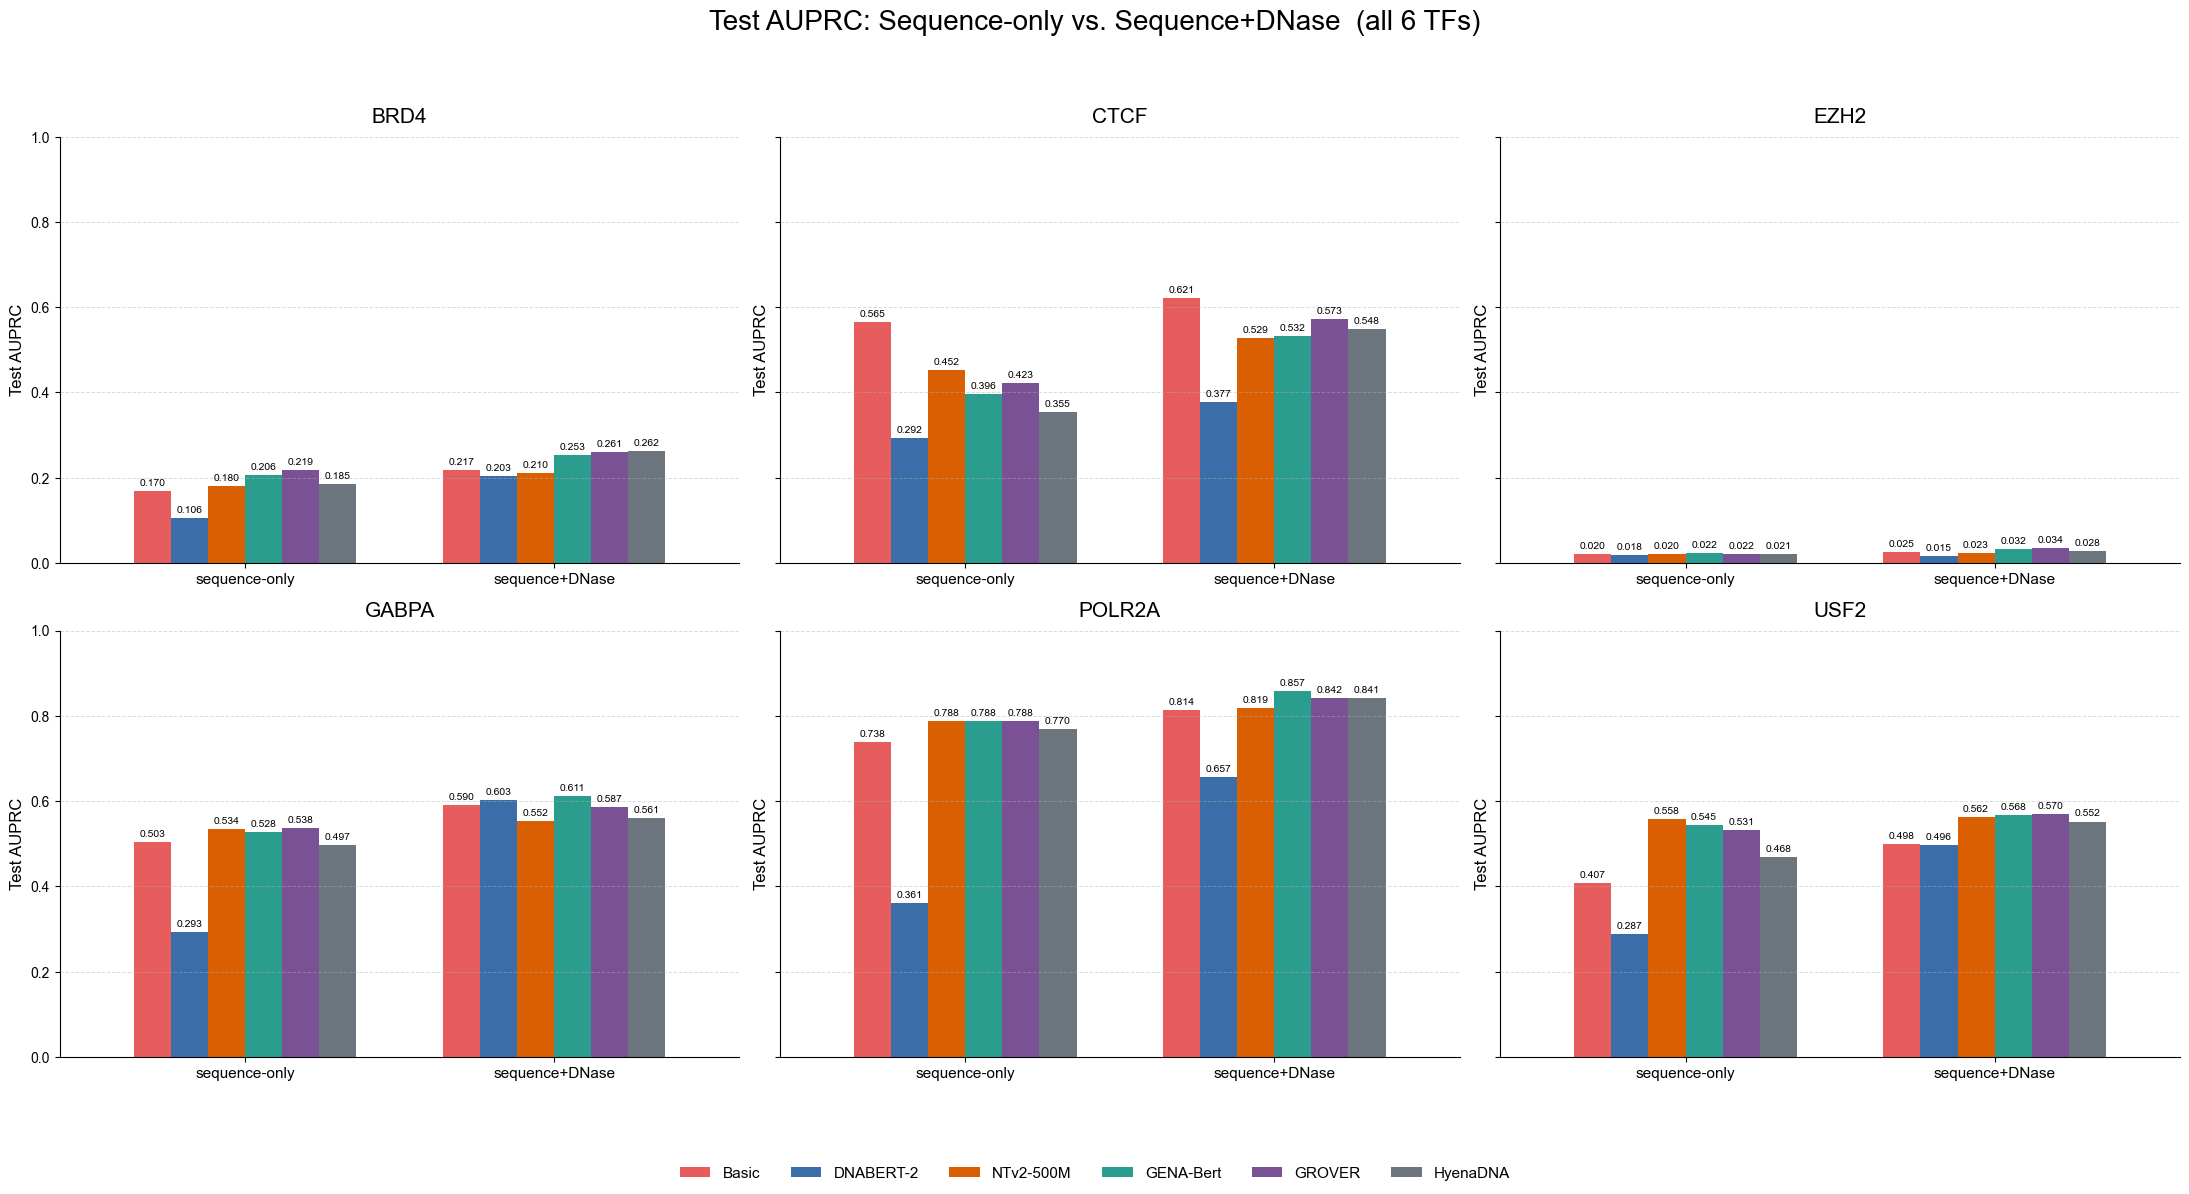

In [7]:
def plot_comparison(seq_only: np.ndarray, with_dnase: np.ndarray,
                    ylabel: str, title: str, save_path: str = None):
    model_keys = list(MODEL_LABELS.keys())
    labels = [MODEL_LABELS[k] for k in model_keys]
    colors = [MODEL_COLORS[k] for k in model_keys]

    width = 0.12
    group_centers = np.array([-0.5, 0.5])
    offsets = (np.arange(len(model_keys)) - (len(model_keys) - 1) / 2) * width

    fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey=True)
    axes = axes.flatten()

    for ti, tf in enumerate(TF_LIST):
        ax = axes[ti]
        for mi in range(len(model_keys)):
            y = [seq_only[mi, ti], with_dnase[mi, ti]]
            bars = ax.bar(group_centers + offsets[mi], y, width=width,
                          label=labels[mi] if ti == 0 else None,
                          color=colors[mi])
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h):
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                            f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

        ax.set_title(tf, fontsize=15, pad=10)
        ax.set_xticks(group_centers)
        ax.set_xticklabels(['sequence-only', 'sequence+DNase'], fontsize=11)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    handles, leg_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, leg_labels, loc='lower center',
               ncol=len(model_keys), frameon=False, fontsize=11)
    fig.suptitle(title, fontsize=20, y=0.985)
    fig.tight_layout(rect=(0, 0.08, 1, 0.95))

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

plot_comparison(
    seq_only, with_dnase,
    ylabel='Test AUPRC',
    title='Test AUPRC: Sequence-only vs. Sequence+DNase  (all 6 TFs)',
    save_path='../figures/auprc_transfer_test_6tf_subplots.pdf',
)

### AUPRC delta (DNase gain)

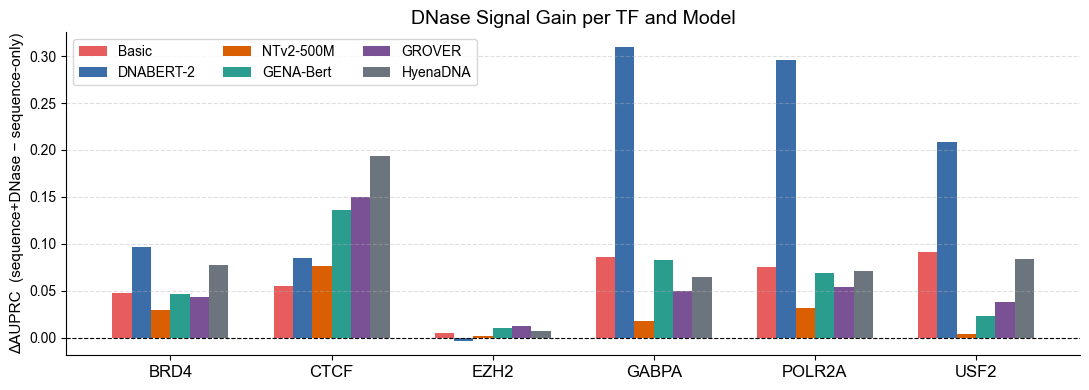


Mean ΔAUPRC per model:
  Basic       : +0.0602 (n=6)
  DNABERT-2   : +0.1654 (n=6)
  NTv2-500M   : +0.0269 (n=6)
  GENA-Bert   : +0.0614 (n=6)
  GROVER      : +0.0578 (n=6)
  HyenaDNA    : +0.0828 (n=6)


In [8]:
delta = with_dnase - seq_only   # (n_models, n_tfs)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(TF_LIST))
bar_width = 0.12
model_keys = list(MODEL_LABELS.keys())

for mi, mk in enumerate(model_keys):
    offsets = (mi - (len(model_keys) - 1) / 2) * bar_width
    ax.bar(x + offsets, delta[mi], width=bar_width,
           label=MODEL_LABELS[mk], color=MODEL_COLORS[mk])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(TF_LIST, fontsize=12)
ax.set_ylabel('ΔAUPRC  (sequence+DNase − sequence-only)', fontsize=11)
ax.set_title('DNase Signal Gain per TF and Model', fontsize=14)
ax.legend(fontsize=10, ncol=3)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nMean ΔAUPRC per model:')
for mi, mk in enumerate(model_keys):
    valid = delta[mi][~np.isnan(delta[mi])]
    if len(valid):
        print(f'  {MODEL_LABELS[mk]:<12}: {valid.mean():+.4f} (n={len(valid)})')

---
## Summary

| Section | What was shown |
|---------|----------------|
| Architecture | GROVER backbone + 1D-CNN DNase fusion; only ~1% of params trainable (frozen backbone) |
| Smoke test   | 1 epoch on 500 CTCF samples – confirms pipeline integrity |
| Full results | Pre-computed AUPRC for all 6 TFs × 6 model families |
| DNase gain   | ΔAUPRC shows consistent improvement across most TF/model combinations |

To regenerate all results from scratch:
```bash
for TF in BRD4 CTCF EZH2 GABPA POLR2A USF2; do
    bash scripts/04_finetune_BPE.sh $TF --model_name GROVER
    bash scripts/05_finetune_NT.sh  $TF
    bash scripts/06_finetune_hyena.sh $TF
done
bash scripts/08_plot_auprc.sh
```